# Experiment 0.1 — General Comparison

Analysis-only notebook for the finalized Exp0.1 General Comparison artifacts.

Primary systems: `short_mid_long`, `short_mid`, `mid_long`, `(234)->(234) + Fixed250 Linear`, `Raw Fixed250 + Linear`, and `Raw Relative10 + Linear`.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'AGENTS.md').exists():
    ROOT = ROOT.parent
ART = ROOT / 'notebooks' / 'artifacts' / 'experiment_0_1_general_comparison' / 'general_comparison_v1'
RUNS = pd.read_csv(ART / 'runs.csv')
SUMMARY = pd.read_csv(ART / 'summary.csv')
BASELINES = pd.read_csv(ART / 'baseline_results.csv')
COMPARISON = pd.read_csv(ART / 'comparison_summary.csv')
CAPACITY = pd.read_csv(ART / 'paired_capacity_effects.csv')
OBJECTIVE = pd.read_csv(ART / 'paired_objective_effects.csv')
ARCH = pd.read_csv(ART / 'paired_architecture_effects.csv')
with (ART / 'manifest.json').open('r', encoding='utf-8') as handle:
    MANIFEST = json.load(handle)
ART


PosixPath('/home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_0_1_general_comparison/general_comparison_v1')

## Overall comparison

The common table compares every trained SNN system with the two deterministic raw baselines: **Raw Fixed250 + Linear** and **Raw Relative10 + Linear**.

In [2]:
display(COMPARISON.sort_values('mean_test_ba', ascending=False).reset_index(drop=True))


,system,family,architecture,objective,variant,mean_test_ba,sd_test_ba,n
0,Raw Relative10 + Linear,raw_linear_baseline,relative10,posthoc_linear,deterministic,0.739481,NaN,1
1,snn_fixed250_linear:local_234x2:timestep_ce:mu...,snn_fixed250_linear,local_234x2,timestep_ce,multi_h,0.600974,0.014364,5
2,snn_fixed250_linear:local_234x2:timestep_ce:bi...,snn_fixed250_linear,local_234x2,timestep_ce,binary,0.595437,0.032058,5
3,Raw Fixed250 + Linear,raw_linear_baseline,fixed250,posthoc_linear,deterministic,0.548475,NaN,1
4,direct_snn:short_mid:whole_count_ce:binary,direct_snn,short_mid,whole_count_ce,binary,0.457210,0.026985,5
5,direct_snn:short_mid:whole_count_ce:multi_h,direct_snn,short_mid,whole_count_ce,multi_h,0.434573,0.024067,5
6,direct_snn:mid_long:whole_count_ce:multi_h,direct_snn,mid_long,whole_count_ce,multi_h,0.413762,0.011693,5
7,direct_snn:mid_long:whole_count_ce:binary,direct_snn,mid_long,whole_count_ce,binary,0.400790,0.030637,5
8,direct_snn:mid_long:timestep_ce:binary,direct_snn,mid_long,timestep_ce,binary,0.304034,0.044997,5
9,direct_snn:short_mid:timestep_ce:multi_h,direct_snn,short_mid,timestep_ce,multi_h,0.292169,0.027146,5


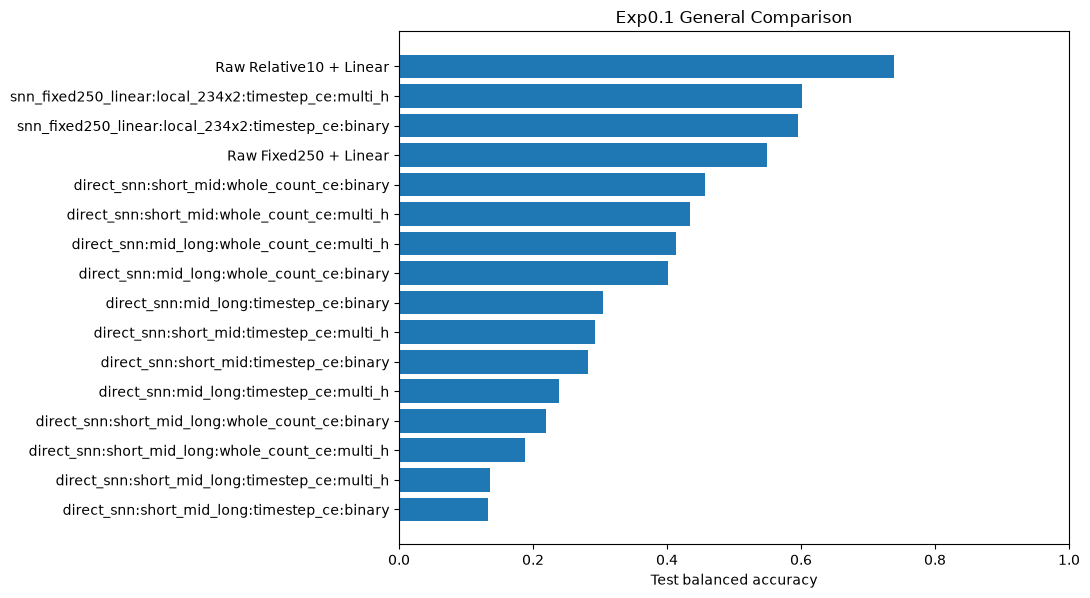

In [3]:
plot_df = COMPARISON.sort_values('mean_test_ba', ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11, max(5, 0.38 * len(plot_df))))
ax.barh(plot_df['system'], plot_df['mean_test_ba'])
ax.set_xlabel('Test balanced accuracy')
ax.set_title('Exp0.1 General Comparison')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()


## Binary vs multi-H hidden communication capacity

Positive values mean hidden event capacity 31 outperforms pure binary hidden spikes.

In [4]:
capacity_summary = (CAPACITY.groupby(['family', 'architecture', 'objective'])['delta_test_ba_multi_h_minus_binary']
                    .agg(['mean', 'std', 'count']).reset_index())
display(capacity_summary.sort_values('mean', ascending=False))


,family,architecture,objective,mean,std,count
1,direct_snn,mid_long,whole_count_ce,0.012973,0.023277,5
2,direct_snn,short_mid,timestep_ce,0.010705,0.029899,5
6,snn_fixed250_linear,local_234x2,timestep_ce,0.005537,0.032961,5
4,direct_snn,short_mid_long,timestep_ce,0.003913,0.026179,5
3,direct_snn,short_mid,whole_count_ce,-0.022637,0.044698,5
5,direct_snn,short_mid_long,whole_count_ce,-0.030184,0.018340,5
0,direct_snn,mid_long,timestep_ce,-0.065357,0.072137,5


## Timestep CE vs WholeCount CE

This comparison is restricted to the direct SNN families. Final inference remains Output WholeCount in both cases.

In [5]:
objective_summary = (OBJECTIVE.groupby(['architecture', 'variant'])['delta_test_ba_timestep_minus_whole_count']
                     .agg(['mean', 'std', 'count']).reset_index())
display(objective_summary.sort_values('mean', ascending=False))


,architecture,variant,mean,std,count
5,short_mid_long,multi_h,-0.052522,0.028910,5
4,short_mid_long,binary,-0.086619,0.025193,5
0,mid_long,binary,-0.096756,0.031753,5
3,short_mid,multi_h,-0.142404,0.040587,5
1,mid_long,multi_h,-0.175085,0.061238,5
2,short_mid,binary,-0.175747,0.030838,5


## Temporal hierarchy effects

`add_long_layer`: `short_mid_long - short_mid`.  
`shift_coverage_longer`: `mid_long - short_mid`.

In [6]:
arch_summary = (ARCH.groupby(['comparison', 'objective', 'variant'])['delta_test_ba']
                .agg(['mean', 'std', 'count']).reset_index())
display(arch_summary.sort_values(['comparison', 'mean'], ascending=[True, False]))


,comparison,objective,variant,mean,std,count
0,add_long_layer,timestep_ce,binary,-0.149359,0.029625,5
1,add_long_layer,timestep_ce,multi_h,-0.156151,0.030893,5
2,add_long_layer,whole_count_ce,binary,-0.238487,0.023353,5
3,add_long_layer,whole_count_ce,multi_h,-0.246034,0.038623,5
4,shift_coverage_longer,timestep_ce,binary,0.022571,0.045432,5
7,shift_coverage_longer,whole_count_ce,multi_h,-0.020811,0.015273,5
5,shift_coverage_longer,timestep_ce,multi_h,-0.053492,0.045540,5
6,shift_coverage_longer,whole_count_ce,binary,-0.056420,0.026179,5


## Raw baseline anchors

In [7]:
display(BASELINES[['system', 'feature_dim', 'probe_C', 'val_ba', 'test_ba', 'test_accuracy', 'test_macro_f1']])


,system,feature_dim,probe_C,val_ba,test_ba,test_accuracy,test_macro_f1
0,Raw Fixed250 + Linear,480,0.10,0.587290,0.548475,0.554795,0.537217
1,Raw Relative10 + Linear,300,0.01,0.622739,0.739481,0.760274,0.745279


## Training stability / per-seed inspection

In [8]:
display(RUNS.sort_values(['family', 'architecture', 'objective', 'variant', 'seed']).reset_index(drop=True))


,family,architecture,objective,variant,hidden_cap,output_cap,seed,primary_readout,best_epoch,train_ba,val_ba,test_ba,test_accuracy,test_macro_f1,native_test_ba,test_last_hidden_events_per_neuron_second
0,direct_snn,mid_long,timestep_ce,binary,1,1.0,11,output_whole_count,62,0.497918,0.308171,0.346183,0.363014,0.272140,0.346183,8.536904
1,direct_snn,mid_long,timestep_ce,binary,1,1.0,23,output_whole_count,100,0.629167,0.289087,0.328177,0.349315,0.279349,0.328177,11.262260
2,direct_snn,mid_long,timestep_ce,binary,1,1.0,37,output_whole_count,100,0.602454,0.262572,0.249917,0.260274,0.192613,0.249917,7.959203
3,direct_snn,mid_long,timestep_ce,binary,1,1.0,53,output_whole_count,87,0.543855,0.260913,0.260956,0.273973,0.189606,0.260956,6.772449
4,direct_snn,mid_long,timestep_ce,binary,1,1.0,71,output_whole_count,78,0.597813,0.311177,0.334939,0.349315,0.268675,0.334939,7.132911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,snn_fixed250_linear,local_234x2,timestep_ce,multi_h,31,NaN,11,l2_fixed250_ordered_linear,88,0.937242,0.511706,0.610132,0.630137,0.619690,0.498312,68.683524
66,snn_fixed250_linear,local_234x2,timestep_ce,multi_h,31,NaN,23,l2_fixed250_ordered_linear,86,0.926097,0.499339,0.619789,0.636986,0.614425,0.524142,60.102344
67,snn_fixed250_linear,local_234x2,timestep_ce,multi_h,31,NaN,37,l2_fixed250_ordered_linear,87,0.976089,0.536580,0.584821,0.602740,0.592888,0.502799,55.400472
68,snn_fixed250_linear,local_234x2,timestep_ce,multi_h,31,NaN,53,l2_fixed250_ordered_linear,98,0.914116,0.526984,0.589743,0.602740,0.581020,0.459843,63.916004
